In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from nflows import flows, transforms, distributions

from src.diffeomorphisms.vector.nflow import NFlowVectorDiffeomorphism
from src.diffeomorphisms.vector.nflow.fixed_origin import FixedOriginNFlowVectorDiffeomorphism
from src.dimension_reduction.principal_geodesic_analysis.vector.l2_tangent_space_pca import l2TangentSpacePCAVectorSolver
from src.inverse_problem_solver.ambient_flow import AmbientFlowSolver
from src.manifolds.euclidean.vector.pullback.standard import StandardPullbackVectorEuclidean
from src.nn.module.polynomial_activation import PolynomialActivation
from src.transforms.lower_triangular_linear import LowerTriangularLinearTransform
from src.transforms.upper_triangular_linear import UpperTriangularLinearTransform
from src.transforms.polynomial_parity import PolynomialParityTransform

device = "cuda" if torch.cuda.is_available() else "cpu"

# Set random seed for reproducibility
torch.manual_seed(31)

### Learning Geometry ###

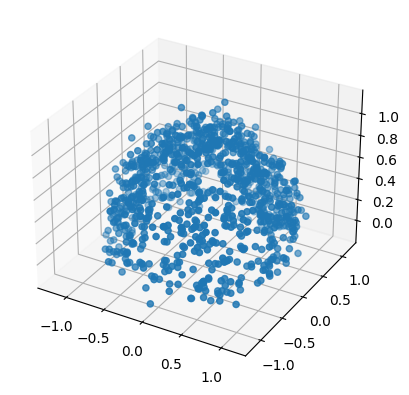

In [2]:
# Construct dataset
def uniform_sphere_sampling(dim, num_samples):
    """
    Generate uniform samples on a unit sphere in dim dimensions using PyTorch.
    """
    samples = torch.randn(num_samples, dim)
    samples /= torch.norm(samples, dim=1, keepdim=True)
    samples[:,2] *= torch.sign(samples[:,2])
    return samples

num_samples = 1000
noise_level = 0.1

data_train_clean = uniform_sphere_sampling(3, num_samples)
data_train = data_train_clean + noise_level * torch.randn_like(data_train_clean)

train_loader = DataLoader(data_train, batch_size=128, shuffle=False)

# plot data
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
plt.show()

In [3]:
class IdentityForward(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return x

In [4]:
# Define the normalizing flow model
def create_flow_model(dim, n_flows, order, unit_det=False):
    base_dist = distributions.StandardNormal(shape=[dim])
    transforms_list = []
    for i in range(n_flows):
        transforms_list.append(UpperTriangularLinearTransform(dim, unit_det=unit_det))
        transforms_list.append(LowerTriangularLinearTransform(dim, unit_det=unit_det))
        transforms_list.append(PolynomialParityTransform(dim, order, parity=i))
    transforms_list.append(UpperTriangularLinearTransform(dim, unit_det=unit_det))
    transforms_list.append(LowerTriangularLinearTransform(dim, unit_det=unit_det))
    flow_transforms = transforms.CompositeTransform(transforms_list)
    return flows.Flow(transform=flow_transforms, distribution=base_dist)

In [5]:
# Define the conditional normalizing flow model
def create_conditional_flow_model(dim, n_flows, order, unit_det=False):
    base_dist = distributions.ConditionalDiagonalNormal(shape=[dim], context_encoder=nn.Linear(dim, 2 * dim))
    transforms_list = []
    for i in range(n_flows):
        transforms_list.append(UpperTriangularLinearTransform(dim, unit_det=unit_det))
        transforms_list.append(LowerTriangularLinearTransform(dim, unit_det=unit_det))
        transforms_list.append(PolynomialParityTransform(dim, order=order, parity=i))
    transforms_list.append(UpperTriangularLinearTransform(dim, unit_det=unit_det))
    transforms_list.append(LowerTriangularLinearTransform(dim, unit_det=unit_det))
    flow_transforms = transforms.CompositeTransform(transforms_list)
    return flows.Flow(transform=flow_transforms, distribution=base_dist)


In [6]:
# Initialize the model
forward = IdentityForward()

dim = 3
n_flows = 2
flow = create_flow_model(dim, n_flows, 2)
prior_diffeo = NFlowVectorDiffeomorphism(dim, flow)
# origin = torch.tensor([0.,0.,1.])
# prior_diffeo = FixedOriginNFlowVectorDiffeomorphism(prior_diffeo_, origin)

n_layers = 2
c_flow = create_conditional_flow_model(dim, n_flows, 2)
posterior_diffeo = NFlowVectorDiffeomorphism(dim, c_flow)

sparsity_level = 2
model = AmbientFlowSolver(forward, prior_diffeo, posterior_diffeo, noise_level, sparsity_level).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [7]:
# Training loop
def train(model, train_loader, optimizer, n_epochs, l1_weight):
    for epoch in range(n_epochs):
        for _, y in enumerate(train_loader):
            optimizer.zero_grad()
            
            # Compute loss
            loss = model.reconstruction_loss(y)

            # Compute regularization on polynomial coefficients
            l1_norm_phi = 0
            for module in model.phi.nflow.modules():
                if isinstance(module, PolynomialParityTransform):
                    # Access the submodule containing activation layers
                    for submodule in module.modules():
                        if isinstance(submodule, PolynomialActivation):
                            if hasattr(submodule, 'coefficients'):
                                # Sum absolute values of polynomial coefficients
                                l1_norm_phi += torch.sum(torch.abs(submodule.coefficients))
            loss += l1_weight * l1_norm_phi

            # Compute regularization on polynomial coefficients
            l1_norm_phy = 0
            for module in model.phy.nflow.modules():
                if isinstance(module, PolynomialParityTransform):
                    # Access the submodule containing activation layers
                    for submodule in module.modules():
                        if isinstance(submodule, PolynomialActivation):
                            if hasattr(submodule, 'coefficients'):
                                # Sum absolute values of polynomial coefficients
                                l1_norm_phy += torch.sum(torch.abs(submodule.coefficients))
            loss += l1_weight * l1_norm_phy

            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}")

In [8]:
# Train the model
n_epochs = 500
l1_weight = 0.01
train(model, train_loader, optimizer, n_epochs, l1_weight)

Epoch 1/500, Loss: 61.7594
Epoch 2/500, Loss: 56.7938
Epoch 3/500, Loss: 46.9743
Epoch 4/500, Loss: 42.7304
Epoch 5/500, Loss: 41.8370
Epoch 6/500, Loss: 33.1706
Epoch 7/500, Loss: 30.7296
Epoch 8/500, Loss: 31.3894
Epoch 9/500, Loss: 30.9020
Epoch 10/500, Loss: 26.4381
Epoch 11/500, Loss: 27.8298
Epoch 12/500, Loss: 26.6937
Epoch 13/500, Loss: 23.2303
Epoch 14/500, Loss: 24.3486
Epoch 15/500, Loss: 17.5977
Epoch 16/500, Loss: 20.9552
Epoch 17/500, Loss: 19.2950
Epoch 18/500, Loss: 18.4046
Epoch 19/500, Loss: 21.6683
Epoch 20/500, Loss: 17.7633
Epoch 21/500, Loss: 18.1011
Epoch 22/500, Loss: 16.9394
Epoch 23/500, Loss: 18.7608
Epoch 24/500, Loss: 18.2094
Epoch 25/500, Loss: 16.4166
Epoch 26/500, Loss: 17.3462
Epoch 27/500, Loss: 17.7328
Epoch 28/500, Loss: 17.6691
Epoch 29/500, Loss: 16.7362
Epoch 30/500, Loss: 14.4741
Epoch 31/500, Loss: 14.4952
Epoch 32/500, Loss: 15.1089
Epoch 33/500, Loss: 15.3418
Epoch 34/500, Loss: 15.5989
Epoch 35/500, Loss: 14.8098
Epoch 36/500, Loss: 13.6148
E

In [9]:
# Generate samples
@torch.no_grad()
def generate_samples(model, n_samples):
    samples = model.sample(n_samples).cpu()
    return samples

In [10]:
@torch.no_grad()
def generate_samples_with_context(model, n_samples, context):
    samples = model.sample(n_samples, context=context[None]).squeeze().cpu()
    return samples

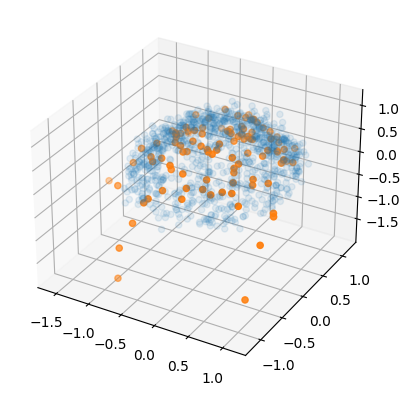

In [11]:
# Visualize generated samples
samples = generate_samples(model.phi.nflow, 100)

ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2],alpha=0.1)
ax.scatter(samples[:,0], samples[:,1], samples[:,2])
plt.show()

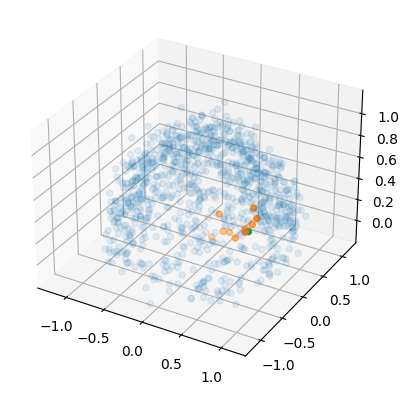

In [25]:
# Visualize generated samples
context = data_train[8]
samples = generate_samples_with_context(model.phy.nflow, 10, context)

ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2],alpha=0.1)
ax.scatter(samples[:,0], samples[:,1], samples[:,2])
ax.scatter(context[0], context[1], context[2])
plt.show()

### Evaluating Geometry ###

In [13]:
# Construct pullback manifold
manifold = StandardPullbackVectorEuclidean(model.phi)

In [14]:
# special points
x0 = torch.tensor([0.,0.,1.]).to(device)
x1 = torch.tensor([1.,0.,0.]).to(device)

In [15]:
# test interpolation
t = torch.linspace(0.,1.,20).to(device)

geodesic_x0_x1 = manifold.geodesic(x0,x1,t).detach().cpu().numpy()

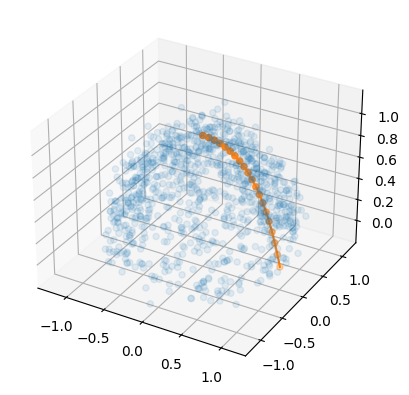

In [16]:
# plot geodesics
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.plot(geodesic_x0_x1[:,0], geodesic_x0_x1[:,1], geodesic_x0_x1[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
ax.scatter(geodesic_x0_x1[:,0], geodesic_x0_x1[:,1], geodesic_x0_x1[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [17]:
# compute barycentre
bary = manifold.barycentre(data_train.to(device))
print(bary)
print(data_train.mean(0))

tensor([0.0926, 0.1923, 0.8971], grad_fn=<SelectBackward0>)
tensor([0.0321, 0.0136, 0.4825])


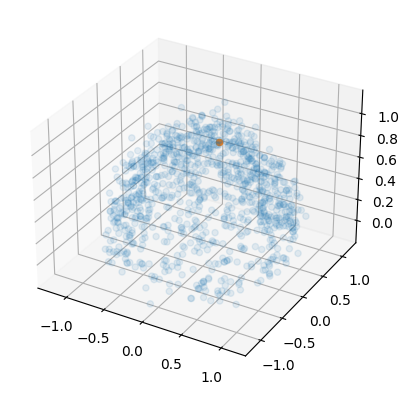

In [18]:
# plot barycentres
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.scatter(bary.detach().cpu().numpy()[0], bary.detach().cpu().numpy()[1], bary.detach().cpu().numpy()[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [19]:
# construct curvature corrected l2-pga solver
l2_pga_solver = l2TangentSpacePCAVectorSolver(data_train.to(device), manifold, bary)

In [20]:
# compute low rank approximations
l2_pga_solver.solve(2) # compute rank 2 approximation

Computing rank 2 approximation on tangent space
Computing rank 2 approximation on euclidean space
Computing rank 2 errors


In [21]:
# compute approximations
approximations = l2_pga_solver.exp_x_Xi[2]

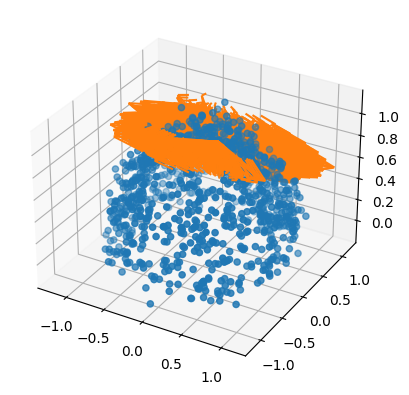

In [22]:
# plot tangent space approximations
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
ax.scatter(bary.detach().cpu().numpy()[0], bary.detach().cpu().numpy()[1], bary.detach().cpu().numpy()[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
for i in range(l2_pga_solver.log_x_data.shape[0]):
    ax.quiver(bary.detach().cpu().numpy()[0], bary.detach().cpu().numpy()[1], bary.detach().cpu().numpy()[2], 
             l2_pga_solver.Xi[2].detach().cpu().numpy()[i, 0], l2_pga_solver.Xi[2].detach().cpu().numpy()[i, 1], l2_pga_solver.Xi[2].detach().cpu().numpy()[i, 2], 
             color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()


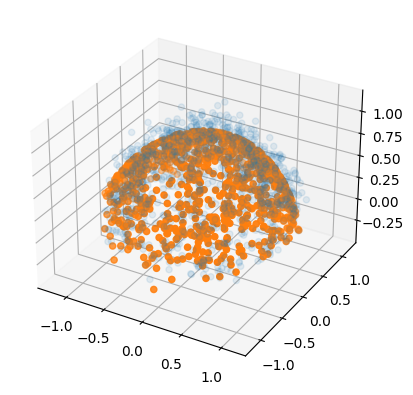

In [23]:
# plot data approximations
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.scatter(approximations.detach().cpu().numpy()[:,0], approximations.detach().cpu().numpy()[:,1], approximations.detach().cpu().numpy()[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [24]:
# compute approximation errors
print(torch.mean((data_train.to(device) - approximations)**2,0).sum())

tensor(0.0277, grad_fn=<SumBackward0>)
